# Modelos — Etapa 1: Baselines

Pipeline: EDA → limpeza de tipos → tratamento de "No service" → features derivadas → split treino/teste → fit do encoder+scaler no treino → transform em ambos → **baseline (Dummy + LR)**

Métricas avaliadas:
- **Técnicas**: Accuracy, F1-Score, Precision, Recall, ROC-AUC, PR-AUC
- **Negócio**: Custo de churn evitado (TP), custo falso positivo (FP), churn perdido (FN), lucro líquido

## Setup

In [1]:
import pandas as pd
import numpy as np
import random
import hashlib
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from utils import (
    preprocess,
    split_data,
    scale_numeric,
    pos_weight_balanced,
    lucro_liquido,
    find_threshold_max_profit,
    find_threshold_max_f1,
    find_threshold_min_recall,
    calibrate_probas,
)

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TEST_SIZE = 0.2

## Carregamento e Pré-processamento

In [2]:
DATASET_PATH = "../data/dataset/telco_customer_churn.csv"

df_raw = pd.read_csv(DATASET_PATH)
df = df_raw.copy()
df.rename(columns={"Churn": "target"}, inplace=True)
df["target"] = df["target"].map({"Yes": 1, "No": 0})

# Versionamento do dataset
with open(DATASET_PATH, "rb") as f:
    DATASET_VERSION = hashlib.md5(f.read()).hexdigest()
print(f"Dataset MD5: {DATASET_VERSION}")
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True).round(4)}")

Dataset MD5: 0f9de68e012bd3aed5fa7cdc9fc421af
Shape: (7043, 21)
Target distribution:
target
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [3]:
# Pipeline minimalista compartilhado: limpeza + one-hot encoding (sem scaling)
df_encoded = preprocess(df)

# Split com val (baselines ignoram val); MinMaxScaler é aplicado só no MLP, não aqui
X_train, _, X_test, y_train, _, y_test = split_data(
    df_encoded, test_size=TEST_SIZE, random_state=SEED
)

print(f"Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Target rate (treino): {y_train.mean():.4f}")

Treino: 4500 amostras, 26 features
Teste:  1407 amostras
Target rate (treino): 0.2658


## Função de Avaliação

Métricas técnicas + duas métricas de negócio complementares:

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| LTV por cliente retido (TP) | R$ 500 | Receita preservada ao reter um cliente que churaria |
| Custo de retenção (TP + FP) | R$ 100 | Custo da campanha/desconto oferecido |

| Métrica de negócio | Fórmula | Pergunta que responde |
|--------------------|---------|----------------------|
| **ROI Campanha** | `ganho_tp - custo_fp` | "A campanha de retenção se paga?" |
| **Lucro Líquido** | `ganho_tp - custo_fp - perda_fn` | "Qual o impacto econômico total de usar este modelo?" |

In [4]:
VALOR_CLIENTE_LTV = 500  # Ganho ao reter um TP
CUSTO_RETENCAO = 100     # Custo da oferta (desconto/cupom) para TP e FP


def evaluate_model(model, X_test, y_test):
    """Avalia modelo com métricas técnicas e de negócio. Retorna dict de métricas e confusion matrix."""
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = np.zeros(len(y_test))

    # Métricas técnicas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1)
    roc = roc_auc_score(y_test, y_proba) if y_proba.sum() > 0 else 0.5
    pr_prec, pr_rec, _ = precision_recall_curve(y_test, y_proba)
    pr = auc(pr_rec, pr_prec)

    # Métricas de negócio
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ganho_tp = tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO)
    custo_fp = fp * CUSTO_RETENCAO
    perda_fn = fn * VALOR_CLIENTE_LTV
    roi_campanha = ganho_tp - custo_fp                  # ROI da acao de retencao
    lucro_liquido = ganho_tp - custo_fp - perda_fn      # Impacto economico total do modelo

    metrics = {
        "accuracy": acc,
        "f1_score": f1,
        "precision": prec,
        "recall": rec,
        "roc_auc": roc,
        "pr_auc": pr,
        "custo_churn_evitado_BRL": ganho_tp,
        "custo_falso_positivo_BRL": custo_fp,
        "custo_churn_perdido_BRL": perda_fn,
        "roi_campanha_BRL": roi_campanha,
        "lucro_liquido_BRL": lucro_liquido,
    }

    # Print resumo
    print(classification_report(y_test, y_pred, target_names=["Sem churn", "Com churn"]))
    print(f"  ROC-AUC:  {roc:.4f}")
    print(f"  PR-AUC:   {pr:.4f}")
    print(f"  TP Custo churn evitado:  R$ {ganho_tp:,.0f}")
    print(f"  FN Custo churn perdido:  R$ {perda_fn:,.0f}")
    print(f"  FP Custo falso positivo: R$ {custo_fp:,.0f}")
    print(f"  ROI Campanha:            R$ {roi_campanha:,.0f}  (ganho_tp - custo_fp)")
    print(f"  Lucro Liquido:           R$ {lucro_liquido:,.0f}  (ganho_tp - custo_fp - perda_fn)")

    return metrics, cm

## Baseline 1: DummyClassifier

Baseline ingênuo — sempre prediz a classe majoritária (`most_frequent`). Serve como piso: qualquer modelo real precisa superar isso.

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)

print("=" * 60)
print(" DummyClassifier (most_frequent)")
print("=" * 60)
dummy_metrics, dummy_cm = evaluate_model(dummy, X_test, y_test)

 DummyClassifier (most_frequent)
              precision    recall  f1-score   support

   Sem churn       0.73      1.00      0.85      1033
   Com churn       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407

  ROC-AUC:  0.5000
  PR-AUC:   0.6329
  TP Custo churn evitado:  R$ 0
  FN Custo churn perdido:  R$ 187,000
  FP Custo falso positivo: R$ 0
  ROI Campanha:            R$ 0  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ -187,000  (ganho_tp - custo_fp - perda_fn)


## Baseline 2: Regressão Logística

Baseline com `class_weight='balanced'` para compensar o desbalanceamento (~26% churn). Usa solver `lbfgs` com `max_iter=1000`.

In [6]:
lr = LogisticRegression(
    max_iter=1000, random_state=SEED, class_weight="balanced", solver="lbfgs"
)
lr.fit(X_train, y_train)

print("=" * 60)
print(" LogisticRegression (balanced)")
print("=" * 60)
lr_metrics, lr_cm = evaluate_model(lr, X_test, y_test)

 LogisticRegression (balanced)
              precision    recall  f1-score   support

   Sem churn       0.90      0.71      0.79      1033
   Com churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

  ROC-AUC:  0.8350
  PR-AUC:   0.6160
  TP Custo churn evitado:  R$ 118,800
  FN Custo churn perdido:  R$ 38,500
  FP Custo falso positivo: R$ 30,300
  ROI Campanha:            R$ 88,500  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ 50,000  (ganho_tp - custo_fp - perda_fn)


## Comparacao Visual

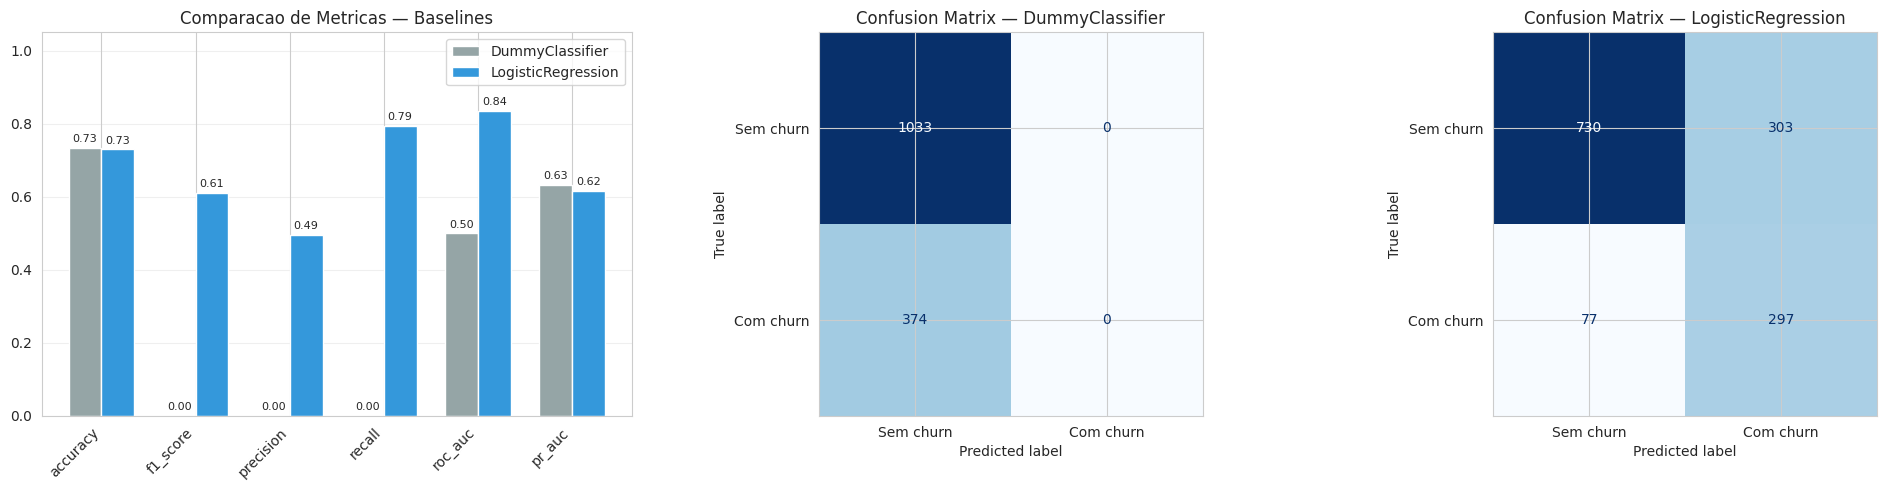

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- 1. Métricas lado a lado ---
metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35
bars1 = axes[0].bar(x - width / 2, dummy_vals, width, label="DummyClassifier", color="#95a5a6")
bars2 = axes[0].bar(x + width / 2, lr_vals, width, label="LogisticRegression", color="#3498db")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparacao de Metricas — Baselines")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8,
    )
for bar in bars2:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8,
    )

# --- 2. Confusion Matrix — Dummy ---
ConfusionMatrixDisplay(dummy_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("Confusion Matrix — DummyClassifier")

# --- 3. Confusion Matrix — LR ---
ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False
)
axes[2].set_title("Confusion Matrix — LogisticRegression")

plt.tight_layout()
plt.show()

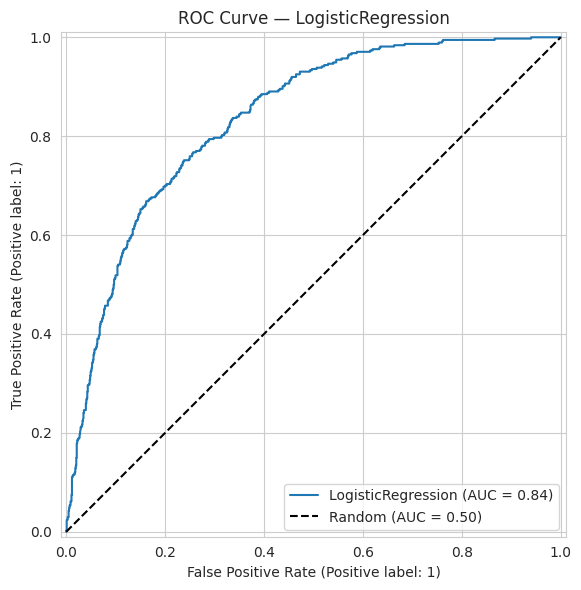

In [8]:
# ROC Curve — somente LR (Dummy com most_frequent não tem curva informativa)
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name="LogisticRegression")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — LogisticRegression")
ax.legend()
plt.tight_layout()
plt.show()

## Resumo dos Baselines

In [9]:
all_metrics = list(dummy_metrics.keys())
resumo = pd.DataFrame({
    "Metrica": all_metrics,
    "DummyClassifier": [dummy_metrics[m] for m in all_metrics],
    "LogisticRegression": [lr_metrics[m] for m in all_metrics],
})

# Formatar valores monetários
for col in ["DummyClassifier", "LogisticRegression"]:
    resumo[col] = resumo.apply(
        lambda row: f"R$ {row[col]:,.0f}" if "BRL" in row["Metrica"] else f"{row[col]:.4f}",
        axis=1,
    )

print("=" * 60)
print(" RESUMO DOS BASELINES")
print("=" * 60)
resumo

 RESUMO DOS BASELINES


,Metrica,DummyClassifier,LogisticRegression
0,accuracy,0.7342,0.7299
1,f1_score,0.0000,0.6099
2,precision,0.0000,0.4950
3,recall,0.0000,0.7941
4,roc_auc,0.5000,0.8350
5,pr_auc,0.6329,0.6160
6,custo_churn_evitado_BRL,R$ 0,"R$ 118,800"
7,custo_falso_positivo_BRL,R$ 0,"R$ 30,300"
8,custo_churn_perdido_BRL,"R$ 187,000","R$ 38,500"
9,roi_campanha_BRL,R$ 0,"R$ 88,500"


## Etapa 2: MLP (PyTorch)

**Objetivo**: superar os baselines com uma rede neural simples em PyTorch, **alinhando o treino e a decisão ao trade-off de negócio** (custo de FN ≈ 5× custo de FP).

**Preprocessamento**:
- Mesma limpeza e one-hot encoding dos baselines (`preprocess`)
- Split estratificado com validation set (`split_data`)
- MinMaxScaler nas 3 features contínuas (`scale_numeric`); features binárias e dummies ficam intactas

**Arquitetura** (`ChurnMLP`, em PyTorch):
- 1 hidden layer com 20 neurônios (ReLU)
- Output linear de 1 neurônio (sigmoid via `BCEWithLogitsLoss`)
- ~561 parâmetros treináveis

**Otimização**:
- Adam (lr=1e-3), `BCEWithLogitsLoss` **com `pos_weight = n_neg / n_pos`** (equivalente ao `class_weight='balanced'` da LR)
- Até 100 épocas com **early stopping no F1 do val** (paciência = 20) — substitui o val_loss, que é dominado pela classe majoritária
- Batch size = 32

**Pós-treino**:
- **Calibração isotônica** das probabilidades no val (sigmoid neural não é calibrada; sem isso, o threshold por lucro opera em escala distorcida)
- **Threshold tuning** no val: comparamos thresholds que maximizam (a) F1, (b) lucro líquido, (c) maior threshold com recall ≥ 0.75

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reprodutibilidade PyTorch
torch.manual_seed(SEED)

# Forçar CPU (versão do PyTorch sem kernels compatíveis com esta GPU)
device = torch.device("cpu")
print(f"Device: {device}")

Device: cpu


### Preparação dos dados (com validation set)

In [11]:
# Reusa o mesmo df_encoded dos baselines (limpeza + one-hot já feitos)
X_train_mlp, X_val_mlp, X_test_mlp, y_train_mlp, y_val_mlp, y_test_mlp = split_data(
    df_encoded, test_size=TEST_SIZE, random_state=SEED
)

# MinMaxScaler aplicado apenas nas 3 features contínuas (fit no treino, transform em val/test)
X_train_mlp, X_val_mlp, X_test_mlp, mlp_scaler = scale_numeric(X_train_mlp, X_val_mlp, X_test_mlp)

print(f"Treino:     {X_train_mlp.shape[0]} amostras, {X_train_mlp.shape[1]} features")
print(f"Validacao:  {X_val_mlp.shape[0]} amostras")
print(f"Teste:      {X_test_mlp.shape[0]} amostras")
print(f"Target rate (treino): {y_train_mlp.mean():.4f}")
print(f"\nFeatures: {list(X_train_mlp.columns)}")

Treino:     4500 amostras, 26 features
Validacao:  1125 amostras
Teste:      1407 amostras
Target rate (treino): 0.2658

Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [12]:
# Converter para tensores PyTorch
def to_tensors(X, y):
    return (
        torch.tensor(X.values.astype(np.float32), dtype=torch.float32),
        torch.tensor(y.values.astype(np.float32), dtype=torch.float32),
    )

X_train_t, y_train_t = to_tensors(X_train_mlp, y_train_mlp)
X_val_t, y_val_t = to_tensors(X_val_mlp, y_val_mlp)
X_test_t, y_test_t = to_tensors(X_test_mlp, y_test_mlp)

# DataLoaders (batch_size=32 para mais updates por epoch em dataset pequeno)
BATCH_SIZE = 32

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False
)

print(f"Batches — treino: {len(train_loader)}, val: {len(val_loader)}, teste: {len(test_loader)}")

Batches — treino: 141, val: 36, teste: 44


### Definição da Arquitetura MLP

In [13]:
class ChurnMLP(nn.Module):
    """MLP em PyTorch com 1 hidden layer (ReLU) + output linear (sigmoid via BCEWithLogitsLoss)."""

    def __init__(self, input_dim, hidden=20):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x).squeeze(-1)  # logit; sigmoid é aplicado em BCEWithLogitsLoss


input_dim = X_train_t.shape[1]
torch.manual_seed(SEED)
model = ChurnMLP(input_dim).to(device)
print(model)
print(f"\nParametros treinaveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

ChurnMLP(
  (fc1): Linear(in_features=26, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)

Parametros treinaveis: 561


### Loop de Treinamento

Loop em PyTorch com **`pos_weight` no BCEWithLogitsLoss** (n_neg / n_pos ≈ 2.77, espelha o `class_weight='balanced'` da LR) e **early stopping no F1 do val** (paciência = 20). A escolha de F1 em vez de val_loss alinha o critério de parada com o objetivo: como BCE médio é dominado pela classe majoritária, ele tende a parar em uma época que minimiza erro nos negativos — exatamente onde recall sofre.

In [14]:
# Hiperparâmetros
EPOCHS = 100
LR = 1e-3
PATIENCE = 20  # F1 é mais granuloso que val_loss, então aumentamos a paciência

# pos_weight = n_neg / n_pos no train (espelha class_weight='balanced' da LR)
pw = pos_weight_balanced(y_train_mlp).to(device)
print(f"pos_weight = {pw.item():.4f}  (n_neg / n_pos no train)")

criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val_f1 = -1.0
best_state = None
epochs_no_improve = 0

train_losses = []
val_losses = []
val_f1s = []
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    # Treino
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validação: loss (para visualização) + F1 @ thr=0.5 (critério de seleção)
    model.eval()
    val_loss = 0.0
    val_logits_full = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * len(X_batch)
            val_logits_full.append(logits.cpu())
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    val_proba = torch.sigmoid(torch.cat(val_logits_full)).numpy()
    val_pred = (val_proba >= 0.5).astype(int)
    val_f1 = f1_score(y_val_mlp.values, val_pred, pos_label=1, zero_division=0)
    val_f1s.append(val_f1)

    # Early stopping por F1 do val (maximizar)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0 or epochs_no_improve == 0:
        marker = " [best]" if epochs_no_improve == 0 else ""
        print(
            f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}{marker}"
        )

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping na epoca {epoch} (paciencia={PATIENCE}, melhor epoca={best_epoch})")
        break

# Restaurar melhor modelo
model.load_state_dict(best_state)
print(f"\nMelhor val F1: {best_val_f1:.4f} (epoca {best_epoch})")
print(f"Epocas treinadas: {len(train_losses)}")

pos_weight = 2.7625  (n_neg / n_pos no train)
Epoch   1 | Train Loss: 0.9216 | Val Loss: 0.8102 | Val F1: 0.5990 [best]
Epoch   2 | Train Loss: 0.7485 | Val Loss: 0.7532 | Val F1: 0.6189 [best]
Epoch   3 | Train Loss: 0.7212 | Val Loss: 0.7452 | Val F1: 0.6212 [best]
Epoch   7 | Train Loss: 0.7054 | Val Loss: 0.7374 | Val F1: 0.6224 [best]
Epoch  10 | Train Loss: 0.7006 | Val Loss: 0.7356 | Val F1: 0.6226 [best]
Epoch  11 | Train Loss: 0.6995 | Val Loss: 0.7364 | Val F1: 0.6238 [best]
Epoch  17 | Train Loss: 0.6925 | Val Loss: 0.7318 | Val F1: 0.6241 [best]
Epoch  20 | Train Loss: 0.6901 | Val Loss: 0.7284 | Val F1: 0.6284 [best]
Epoch  24 | Train Loss: 0.6869 | Val Loss: 0.7278 | Val F1: 0.6291 [best]
Epoch  30 | Train Loss: 0.6827 | Val Loss: 0.7273 | Val F1: 0.6310 [best]
Epoch  34 | Train Loss: 0.6822 | Val Loss: 0.7263 | Val F1: 0.6324 [best]
Epoch  35 | Train Loss: 0.6791 | Val Loss: 0.7256 | Val F1: 0.6350 [best]
Epoch  40 | Train Loss: 0.6763 | Val Loss: 0.7263 | Val F1: 0.6200

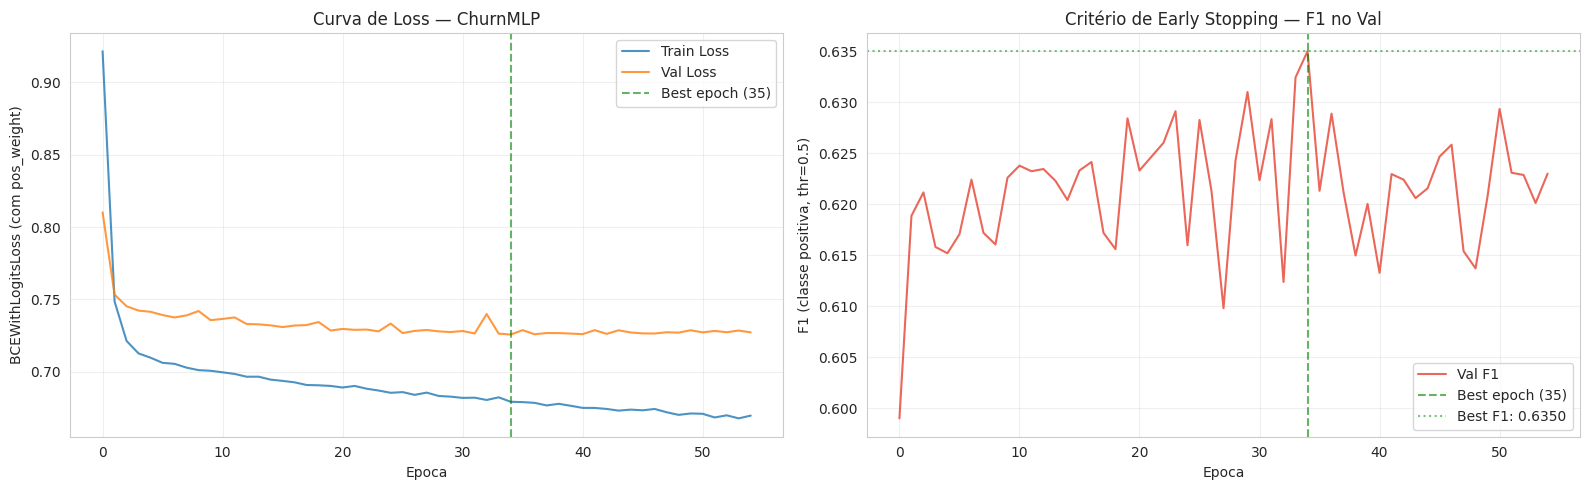

In [15]:
# Curva de aprendizado: loss (train/val) + F1 do val (critério de early stopping)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_losses, label="Train Loss", alpha=0.8)
axes[0].plot(val_losses, label="Val Loss", alpha=0.8)
axes[0].axvline(best_epoch - 1, color="green", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("BCEWithLogitsLoss (com pos_weight)")
axes[0].set_title("Curva de Loss — ChurnMLP")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(val_f1s, label="Val F1", color="#e74c3c", alpha=0.85)
axes[1].axvline(best_epoch - 1, color="green", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
axes[1].axhline(best_val_f1, color="green", linestyle=":", alpha=0.5, label=f"Best F1: {best_val_f1:.4f}")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("F1 (classe positiva, thr=0.5)")
axes[1].set_title("Critério de Early Stopping — F1 no Val")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Calibração + Threshold Tuning no Validation Set

A sigmoid neural não é calibrada por construção — `proba=0.7` não significa "70% de chance de churn". Como queremos comparar 3 thresholds derivados de objetivos distintos (F1, lucro líquido, recall mínimo), o pré-requisito é **fitar uma calibração isotônica no val** para que as probabilidades passem a ter interpretação probabilística confiável.

Em seguida, no **mesmo val (probas calibradas)**, escolhemos 3 thresholds:

| Threshold | Critério | Quando preferir |
|-----------|----------|-----------------|
| `thr_f1`  | maximiza F1 | objetivo balanceado precision/recall |
| `thr_profit` | maximiza lucro líquido (LTV=500, custo=100) | **objetivo primário deste projeto** |
| `thr_rec75` | maior thr com recall ≥ 0.75 | restrição operacional (cobertura mínima) |

Thresholds escolhidos no validation set (probas calibradas):
  thr_f1     = 0.387  -> F1 val     = 0.6350
  thr_profit = 0.060  -> Lucro val  = R$ 66,200
  thr_rec75  = 0.380  -> Recall val = 0.7826


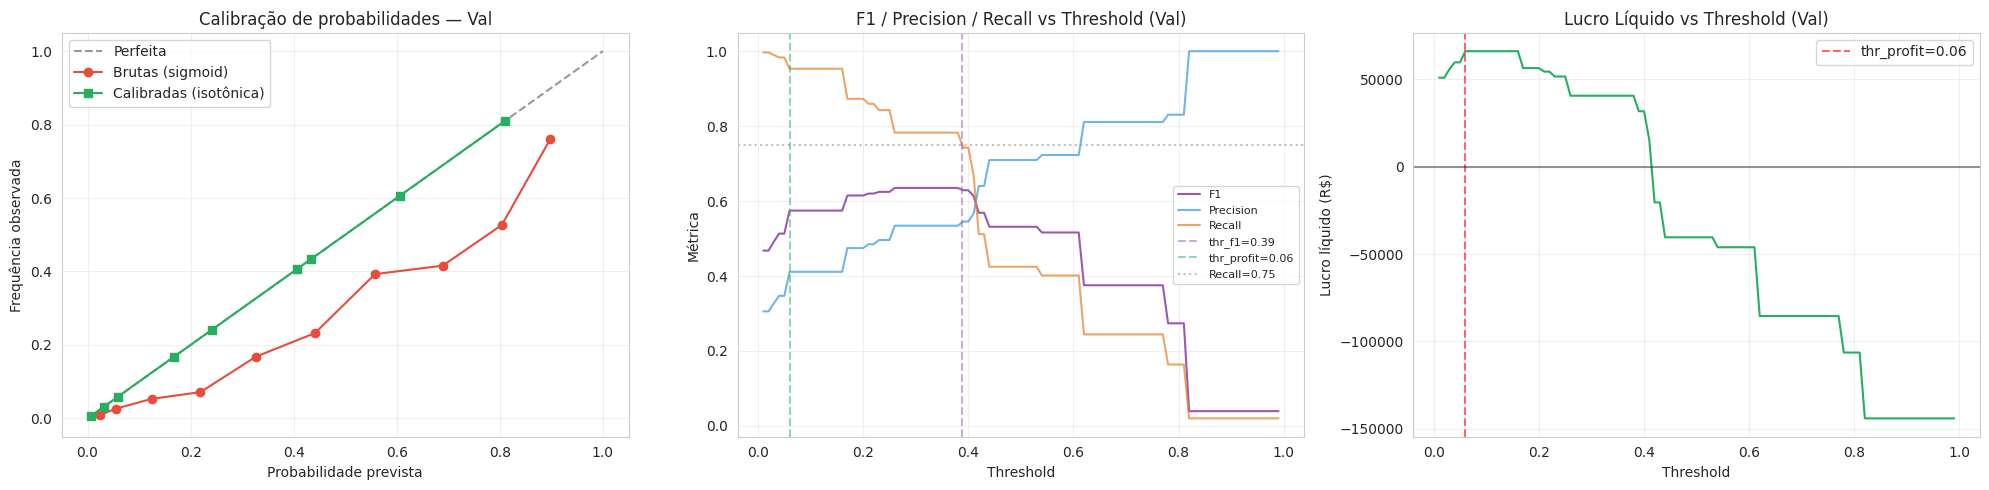

In [16]:
# 1. Probas brutas no val e no test (sigmoid dos logits do modelo treinado)
model.eval()
with torch.no_grad():
    proba_val_raw = torch.sigmoid(model(X_val_t.to(device))).cpu().numpy()
    proba_test_raw = torch.sigmoid(model(X_test_t.to(device))).cpu().numpy()

# 2. Calibração isotônica: fit no val, aplica em val e test
proba_val_cal, proba_test_cal, calibrator = calibrate_probas(
    proba_val_raw, y_val_mlp.values, proba_test_raw
)

# 3. Threshold tuning no val (probas calibradas)
thr_f1, val_f1_at_thr = find_threshold_max_f1(y_val_mlp.values, proba_val_cal)
thr_profit, val_profit_at_thr = find_threshold_max_profit(y_val_mlp.values, proba_val_cal)
thr_rec75, val_rec_at_thr = find_threshold_min_recall(y_val_mlp.values, proba_val_cal, recall_target=0.75)

print("Thresholds escolhidos no validation set (probas calibradas):")
print(f"  thr_f1     = {thr_f1:.3f}  -> F1 val     = {val_f1_at_thr:.4f}")
print(f"  thr_profit = {thr_profit:.3f}  -> Lucro val  = R$ {val_profit_at_thr:,.0f}")
print(f"  thr_rec75  = {thr_rec75:.3f}  -> Recall val = {val_rec_at_thr:.4f}")

# 4. Diagnóstico visual: efeito da calibração + curvas vs threshold
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) Reliability diagram: probas brutas vs calibradas
from sklearn.calibration import calibration_curve
prob_true_raw, prob_pred_raw = calibration_curve(y_val_mlp.values, proba_val_raw, n_bins=10, strategy="quantile")
prob_true_cal, prob_pred_cal = calibration_curve(y_val_mlp.values, proba_val_cal, n_bins=10, strategy="quantile")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfeita")
axes[0].plot(prob_pred_raw, prob_true_raw, "o-", label="Brutas (sigmoid)", color="#e74c3c")
axes[0].plot(prob_pred_cal, prob_true_cal, "s-", label="Calibradas (isotônica)", color="#27ae60")
axes[0].set_xlabel("Probabilidade prevista")
axes[0].set_ylabel("Frequência observada")
axes[0].set_title("Calibração de probabilidades — Val")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) F1 / Precision / Recall vs threshold (no val)
grid = np.arange(0.01, 1.00, 0.01)
f1s = [f1_score(y_val_mlp.values, (proba_val_cal >= t).astype(int), zero_division=0) for t in grid]
precs = [precision_score(y_val_mlp.values, (proba_val_cal >= t).astype(int), zero_division=0) for t in grid]
recs = [recall_score(y_val_mlp.values, (proba_val_cal >= t).astype(int)) for t in grid]
axes[1].plot(grid, f1s, label="F1", color="#9b59b6")
axes[1].plot(grid, precs, label="Precision", color="#3498db", alpha=0.7)
axes[1].plot(grid, recs, label="Recall", color="#e67e22", alpha=0.7)
axes[1].axvline(thr_f1, color="#9b59b6", linestyle="--", alpha=0.5, label=f"thr_f1={thr_f1:.2f}")
axes[1].axvline(thr_profit, color="#27ae60", linestyle="--", alpha=0.5, label=f"thr_profit={thr_profit:.2f}")
axes[1].axhline(0.75, color="gray", linestyle=":", alpha=0.5, label="Recall=0.75")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Métrica")
axes[1].set_title("F1 / Precision / Recall vs Threshold (Val)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# (c) Lucro vs threshold (no val)
profits = [lucro_liquido(y_val_mlp.values, (proba_val_cal >= t).astype(int)) for t in grid]
axes[2].plot(grid, profits, color="#27ae60")
axes[2].axvline(thr_profit, color="red", linestyle="--", alpha=0.6, label=f"thr_profit={thr_profit:.2f}")
axes[2].axhline(0, color="black", alpha=0.4)
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Lucro líquido (R$)")
axes[2].set_title("Lucro Líquido vs Threshold (Val)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Avaliação do MLP no conjunto de teste

Avaliamos 4 variantes no **mesmo test set** para isolar o efeito de cada melhoria:

1. **MLP (default thr=0.5, sem calibração)** — equivale ao MLP original com o novo treino (`pos_weight` + early stop por F1).
2. **MLP + calib + thr_f1** — calibração isotônica + threshold que maximiza F1 no val.
3. **MLP + calib + thr_profit** — calibração + threshold que maximiza lucro no val (variante alinhada ao negócio).
4. **MLP + calib + thr_rec75** — calibração + maior threshold com recall ≥ 0.75 no val.

A escolha de threshold e calibração é feita exclusivamente no val; o test set permanece intocado.

In [17]:
class PyTorchWrapper:
    """Wrapper para usar modelo PyTorch com evaluate_model (interface sklearn).

    Aceita opcionalmente:
      - threshold: corte de decisão (default 0.5)
      - calibrator: objeto com `.transform(proba)` (ex: IsotonicRegression do sklearn)
                    aplicado às probas antes da decisão. Se None, usa probas brutas.
    """

    def __init__(self, model, device, threshold=0.5, calibrator=None):
        self.model = model
        self.device = device
        self.threshold = threshold
        self.calibrator = calibrator

    def predict_proba(self, X):
        self.model.eval()
        if isinstance(X, pd.DataFrame):
            X = torch.tensor(X.values.astype(np.float32), dtype=torch.float32)
        X = X.to(self.device)
        with torch.no_grad():
            logits = self.model(X)
            probs = torch.sigmoid(logits).cpu().numpy()
        if self.calibrator is not None:
            probs = self.calibrator.transform(probs)
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)


# Variante 1: default (thr=0.5, sem calibração) — isola o efeito do novo treino (pos_weight + ES por F1)
mlp_wrapper = PyTorchWrapper(model, device, threshold=0.5, calibrator=None)
print("=" * 60)
print(" MLP (PyTorch) — default thr=0.5, sem calibração")
print("=" * 60)
mlp_metrics, mlp_cm = evaluate_model(mlp_wrapper, X_test_mlp, y_test_mlp)

# Variantes 2-4: calibração + threshold tuning no val
mlp_f1_wrapper = PyTorchWrapper(model, device, threshold=thr_f1, calibrator=calibrator)
print("\n" + "=" * 60)
print(f" MLP + calib + thr_f1 (={thr_f1:.3f})")
print("=" * 60)
mlp_f1_metrics, mlp_f1_cm = evaluate_model(mlp_f1_wrapper, X_test_mlp, y_test_mlp)

mlp_profit_wrapper = PyTorchWrapper(model, device, threshold=thr_profit, calibrator=calibrator)
print("\n" + "=" * 60)
print(f" MLP + calib + thr_profit (={thr_profit:.3f})  <-- objetivo de negócio")
print("=" * 60)
mlp_profit_metrics, mlp_profit_cm = evaluate_model(mlp_profit_wrapper, X_test_mlp, y_test_mlp)

mlp_rec75_wrapper = PyTorchWrapper(model, device, threshold=thr_rec75, calibrator=calibrator)
print("\n" + "=" * 60)
print(f" MLP + calib + thr_rec75 (={thr_rec75:.3f})")
print("=" * 60)
mlp_rec75_metrics, mlp_rec75_cm = evaluate_model(mlp_rec75_wrapper, X_test_mlp, y_test_mlp)

 MLP (PyTorch) — default thr=0.5, sem calibração
              precision    recall  f1-score   support

   Sem churn       0.91      0.71      0.80      1033
   Com churn       0.50      0.80      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

  ROC-AUC:  0.8336
  PR-AUC:   0.6148
  TP Custo churn evitado:  R$ 120,400
  FN Custo churn perdido:  R$ 36,500
  FP Custo falso positivo: R$ 30,200
  ROI Campanha:            R$ 90,200  (ganho_tp - custo_fp)
  Lucro Liquido:           R$ 53,700  (ganho_tp - custo_fp - perda_fn)

 MLP + calib + thr_f1 (=0.387)
              precision    recall  f1-score   support

   Sem churn       0.91      0.71      0.80      1033
   Com churn       0.50      0.80      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      

### Comparação: MLP vs. Baselines

In [18]:
# Tabela comparativa: Baselines vs. todas as variantes do MLP
all_metric_keys = list(dummy_metrics.keys())

# Configuração de cada modelo (threshold + calibração) — anexada como linhas extras no topo
config_rows = pd.DataFrame({
    "Metrica": ["threshold", "calibracao"],
    "DummyClassifier":         [0.5, "Nao"],
    "LogisticRegression":      [0.5, "Nao"],
    "MLP (default)":           [0.5, "Nao"],
    "MLP +calib +thr_f1":      [thr_f1, "Sim (isotonica)"],
    "MLP +calib +thr_profit":  [thr_profit, "Sim (isotonica)"],
    "MLP +calib +thr_rec75":   [thr_rec75, "Sim (isotonica)"],
})

resumo_parcial = pd.DataFrame({
    "Metrica": all_metric_keys,
    "DummyClassifier": [dummy_metrics[m] for m in all_metric_keys],
    "LogisticRegression": [lr_metrics[m] for m in all_metric_keys],
    "MLP (default)": [mlp_metrics[m] for m in all_metric_keys],
    "MLP +calib +thr_f1": [mlp_f1_metrics[m] for m in all_metric_keys],
    "MLP +calib +thr_profit": [mlp_profit_metrics[m] for m in all_metric_keys],
    "MLP +calib +thr_rec75": [mlp_rec75_metrics[m] for m in all_metric_keys],
})

cols_modelos = ["DummyClassifier", "LogisticRegression", "MLP (default)",
                "MLP +calib +thr_f1", "MLP +calib +thr_profit", "MLP +calib +thr_rec75"]
resumo_parcial_display = resumo_parcial.copy()
for col in cols_modelos:
    resumo_parcial_display[col] = resumo_parcial.apply(
        lambda row: f"R$ {row[col]:,.0f}" if "BRL" in row["Metrica"] else f"{row[col]:.4f}",
        axis=1,
    )

# Formatar config: threshold com 3 casas, calibracao como string
config_display = config_rows.copy()
for col in cols_modelos:
    config_display[col] = config_display.apply(
        lambda row: f"{row[col]:.3f}" if row["Metrica"] == "threshold" else str(row[col]),
        axis=1,
    )

resumo_parcial_display = pd.concat([config_display, resumo_parcial_display], ignore_index=True)

print("=" * 100)
print(" COMPARAÇÃO: Baselines vs. MLP (default + 3 variantes calibradas com threshold tuning)")
print("=" * 100)
resumo_parcial_display

 COMPARAÇÃO: Baselines vs. MLP (default + 3 variantes calibradas com threshold tuning)


,Metrica,DummyClassifier,LogisticRegression,MLP (default),MLP +calib +thr_f1,MLP +calib +thr_profit,MLP +calib +thr_rec75
0,threshold,0.500,0.500,0.500,0.387,0.060,0.380
1,calibracao,Nao,Nao,Nao,Sim (isotonica),Sim (isotonica),Sim (isotonica)
2,accuracy,0.7342,0.7299,0.7335,0.7342,0.6247,0.7335
3,f1_score,0.0000,0.6099,0.6162,0.6168,0.5700,0.6162
4,precision,0.0000,0.4950,0.4992,0.5000,0.4098,0.4992
5,recall,0.0000,0.7941,0.8048,0.8048,0.9358,0.8048
6,roc_auc,0.5000,0.8350,0.8336,0.8325,0.8325,0.8325
7,pr_auc,0.6329,0.6160,0.6148,0.6031,0.6031,0.6031
8,custo_churn_evitado_BRL,R$ 0,"R$ 118,800","R$ 120,400","R$ 120,400","R$ 140,000","R$ 120,400"
9,custo_falso_positivo_BRL,R$ 0,"R$ 30,300","R$ 30,200","R$ 30,100","R$ 50,400","R$ 30,200"


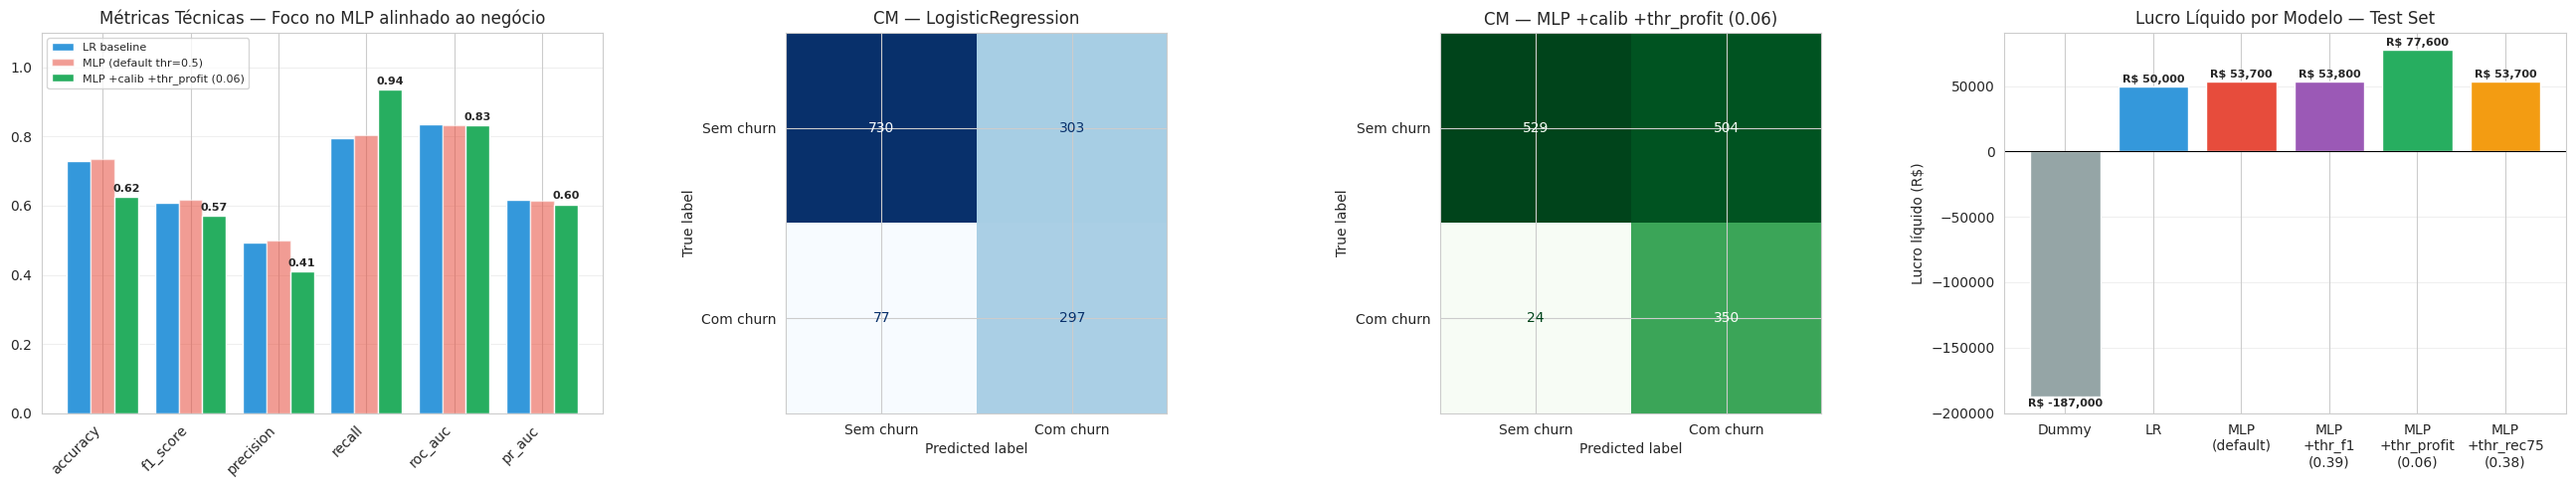

In [19]:
# Visualização comparativa — destaque na variante alinhada ao negócio (thr_profit)
fig, axes = plt.subplots(1, 4, figsize=(26, 5))

# --- 1. Métricas técnicas: LR vs MLP default vs MLP+thr_profit ---
metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
lr_vals = [lr_metrics[m] for m in metric_names]
mlp_vals = [mlp_metrics[m] for m in metric_names]
mlp_profit_vals = [mlp_profit_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.27
axes[0].bar(x - width, lr_vals, width, label="LR baseline", color="#3498db")
axes[0].bar(x, mlp_vals, width, label="MLP (default thr=0.5)", color="#e74c3c", alpha=0.55)
bars_profit = axes[0].bar(x + width, mlp_profit_vals, width, label=f"MLP +calib +thr_profit ({thr_profit:.2f})", color="#27ae60")
for bar in bars_profit:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold",
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Métricas Técnicas — Foco no MLP alinhado ao negócio")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# --- 2. CM — LR ---
ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("CM — LogisticRegression")

# --- 3. CM — MLP +thr_profit ---
ConfusionMatrixDisplay(mlp_profit_cm, display_labels=["Sem churn", "Com churn"]).plot(ax=axes[2], cmap="Greens", colorbar=False)
axes[2].set_title(f"CM — MLP +calib +thr_profit ({thr_profit:.2f})")

# --- 4. Lucro líquido — todas as variantes ---
labels_lucro = ["Dummy", "LR", "MLP\n(default)", f"MLP\n+thr_f1\n({thr_f1:.2f})",
                f"MLP\n+thr_profit\n({thr_profit:.2f})", f"MLP\n+thr_rec75\n({thr_rec75:.2f})"]
lucros = [
    dummy_metrics["lucro_liquido_BRL"],
    lr_metrics["lucro_liquido_BRL"],
    mlp_metrics["lucro_liquido_BRL"],
    mlp_f1_metrics["lucro_liquido_BRL"],
    mlp_profit_metrics["lucro_liquido_BRL"],
    mlp_rec75_metrics["lucro_liquido_BRL"],
]
colors = ["#95a5a6", "#3498db", "#e74c3c", "#9b59b6", "#27ae60", "#f39c12"]
bars = axes[3].bar(labels_lucro, lucros, color=colors)
for bar, val in zip(bars, lucros):
    axes[3].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (3000 if val >= 0 else -8000),
        f"R$ {val:,.0f}", ha="center", fontsize=8, fontweight="bold",
    )
axes[3].set_ylabel("Lucro líquido (R$)")
axes[3].set_title("Lucro Líquido por Modelo — Test Set")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

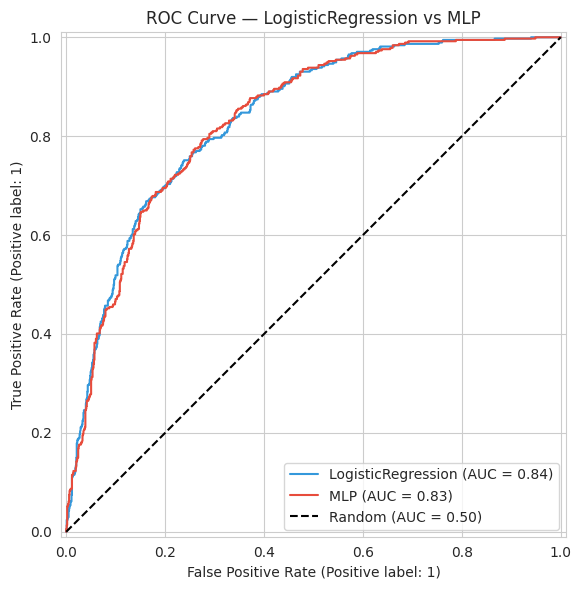

In [20]:
# ROC Curve — LR vs MLP (a curva é igual para todas variantes do MLP — threshold/calibração não mudam ranking)
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name="LogisticRegression", color="#3498db")

# MLP ROC: usa as probas brutas (sem calibração) — calibração isotônica monótona não muda ROC
y_proba_mlp = mlp_wrapper.predict_proba(X_test_mlp)[:, 1]
from sklearn.metrics import RocCurveDisplay as RCD
RCD.from_predictions(y_test_mlp, y_proba_mlp, ax=ax, name="MLP", color="#e74c3c")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — LogisticRegression vs MLP")
ax.legend()
plt.tight_layout()
plt.show()

### Cross-Validation + Grid Search (objetivo: **lucro líquido**)

Validação robusta com `StratifiedKFold(5)`. Mantemos o mesmo espaço de busca da arquitetura simples:
- `hidden`: tamanho da hidden layer (capacidade)
- `lr`: learning rate Adam
- `batch_size`: tamanho do batch

Espaço: 3 × 2 × 2 = **12 configs × 5 folds = 60 treinos**.

- Cada fold treina com `pos_weight` e early stopping no F1 do val (consistente com o pipeline do MLP default).
- **Score de seleção mudou de ROC-AUC para lucro líquido** (com calibração isotônica + threshold tuning por lucro feito no val do fold). ROC-AUC mede ranking; lucro mede impacto da decisão — e nosso objetivo é decisão.
- Reportamos também ROC-AUC para diagnóstico (verificar que o ganho de lucro não vem de degradar o ranking).

In [21]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from itertools import product

from utils import NUMERIC_COLS

# Grid de hiperparâmetros (arquitetura fixa: 1 hidden layer)
param_grid = {
    "hidden":     [16, 20, 32],
    "lr":         [1e-3, 3e-3],
    "batch_size": [32, 64],
}

keys = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Total de configuracoes: {len(combos)}")
print(f"Com 5 folds: {len(combos) * 5} treinos")

# Pool de treino/validação (test set fica intacto)
X_full = df_encoded.drop(columns=["target"])
y_full = df_encoded["target"]
X_cv_pool, X_test_cv, y_cv_pool, y_test_cv = train_test_split(
    X_full, y_full, test_size=TEST_SIZE, random_state=SEED, stratify=y_full
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def train_mlp_fold(X_tr, y_tr, X_vl, y_vl, hidden, lr, batch_size,
                   max_epochs=100, patience=20):
    """Treina ChurnMLP em um fold com pos_weight + early stopping por F1.

    Retorna (lucro_no_val_calibrado_com_thr_otimo, roc_auc_no_val).
    """
    cols = list(NUMERIC_COLS)
    scaler = MinMaxScaler()
    X_tr = X_tr.copy()
    X_vl = X_vl.copy()
    X_tr[cols] = scaler.fit_transform(X_tr[cols])
    X_vl[cols] = scaler.transform(X_vl[cols])

    X_tr_t = torch.tensor(X_tr.values.astype(np.float32))
    y_tr_t = torch.tensor(y_tr.values.astype(np.float32))
    X_vl_t = torch.tensor(X_vl.values.astype(np.float32))
    y_vl_arr = y_vl.values

    train_ds = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)

    torch.manual_seed(SEED)
    mdl = ChurnMLP(X_tr_t.shape[1], hidden=hidden)
    pw_fold = pos_weight_balanced(y_tr)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw_fold)
    opt = torch.optim.Adam(mdl.parameters(), lr=lr)

    best_f1 = -1.0
    best_state = None
    no_improve = 0

    for ep in range(max_epochs):
        mdl.train()
        for xb, yb in train_ds:
            opt.zero_grad()
            loss = crit(mdl(xb), yb)
            loss.backward()
            opt.step()

        mdl.eval()
        with torch.no_grad():
            vl_proba = torch.sigmoid(mdl(X_vl_t)).numpy()
        vl_f1 = f1_score(y_vl_arr, (vl_proba >= 0.5).astype(int), zero_division=0)

        if vl_f1 > best_f1:
            best_f1 = vl_f1
            best_state = {k: v.clone() for k, v in mdl.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    mdl.load_state_dict(best_state)
    mdl.eval()
    with torch.no_grad():
        vl_proba_final = torch.sigmoid(mdl(X_vl_t)).numpy()

    # Calibração isotônica + threshold por lucro no próprio val do fold
    proba_vl_cal, calib = calibrate_probas(vl_proba_final, y_vl_arr)
    _, lucro_vl = find_threshold_max_profit(y_vl_arr, proba_vl_cal)
    auc_vl = roc_auc_score(y_vl_arr, vl_proba_final)
    return lucro_vl, auc_vl


# Grid Search com Cross-Validation
results_cv = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    fold_lucros = []
    fold_aucs = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_cv_pool, y_cv_pool)):
        X_tr_fold = X_cv_pool.iloc[train_idx]
        y_tr_fold = y_cv_pool.iloc[train_idx]
        X_vl_fold = X_cv_pool.iloc[val_idx]
        y_vl_fold = y_cv_pool.iloc[val_idx]
        lucro_val, auc_val = train_mlp_fold(
            X_tr_fold, y_tr_fold, X_vl_fold, y_vl_fold,
            hidden=params["hidden"], lr=params["lr"], batch_size=params["batch_size"],
        )
        fold_lucros.append(lucro_val)
        fold_aucs.append(auc_val)
    mean_lucro = float(np.mean(fold_lucros))
    std_lucro = float(np.std(fold_lucros))
    mean_auc = float(np.mean(fold_aucs))
    results_cv.append({
        **params,
        "mean_lucro_BRL": mean_lucro,
        "std_lucro_BRL": std_lucro,
        "mean_roc_auc": mean_auc,
    })
    print(
        f"[{i+1:2d}/{len(combos)}] {params} -> "
        f"Lucro: R$ {mean_lucro:,.0f} +/- {std_lucro:,.0f} | AUC: {mean_auc:.4f}"
    )

df_cv = pd.DataFrame(results_cv).sort_values("mean_lucro_BRL", ascending=False)
print(f"\n{'='*80}")
print("Top 5 configuracoes (objetivo: lucro líquido):")
print(df_cv.head().to_string(index=False))

Total de configuracoes: 12
Com 5 folds: 60 treinos
[ 1/12] {'hidden': 16, 'lr': 0.001, 'batch_size': 32} -> Lucro: R$ 65,720 +/- 2,991 | AUC: 0.8443
[ 2/12] {'hidden': 16, 'lr': 0.001, 'batch_size': 64} -> Lucro: R$ 64,960 +/- 2,918 | AUC: 0.8416
[ 3/12] {'hidden': 16, 'lr': 0.003, 'batch_size': 32} -> Lucro: R$ 65,720 +/- 3,550 | AUC: 0.8435
[ 4/12] {'hidden': 16, 'lr': 0.003, 'batch_size': 64} -> Lucro: R$ 65,400 +/- 2,813 | AUC: 0.8472
[ 5/12] {'hidden': 20, 'lr': 0.001, 'batch_size': 32} -> Lucro: R$ 65,020 +/- 2,812 | AUC: 0.8433
[ 6/12] {'hidden': 20, 'lr': 0.001, 'batch_size': 64} -> Lucro: R$ 64,400 +/- 2,618 | AUC: 0.8403
[ 7/12] {'hidden': 20, 'lr': 0.003, 'batch_size': 32} -> Lucro: R$ 64,780 +/- 2,993 | AUC: 0.8444
[ 8/12] {'hidden': 20, 'lr': 0.003, 'batch_size': 64} -> Lucro: R$ 65,240 +/- 2,830 | AUC: 0.8444
[ 9/12] {'hidden': 32, 'lr': 0.001, 'batch_size': 32} -> Lucro: R$ 65,600 +/- 3,065 | AUC: 0.8449
[10/12] {'hidden': 32, 'lr': 0.001, 'batch_size': 64} -> Lucro: R$ 

In [22]:
# Retreino final com a melhor configuração (selecionada por lucro líquido em CV)
best_params = df_cv.iloc[0]
print("Melhor configuracao (selecionada por lucro líquido em CV):")
print(f"  hidden:     {int(best_params['hidden'])}")
print(f"  lr:         {best_params['lr']}")
print(f"  batch_size: {int(best_params['batch_size'])}")
print(f"  CV Lucro:   R$ {best_params['mean_lucro_BRL']:,.0f} +/- R$ {best_params['std_lucro_BRL']:,.0f}")
print(f"  CV ROC-AUC: {best_params['mean_roc_auc']:.4f}  (diagnóstico)")

# Split treino/val do pool (val usado para early stopping + calibração + threshold tuning)
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_cv_pool, y_cv_pool, test_size=0.15, random_state=SEED, stratify=y_cv_pool
)

# Scaling (fit no train, transform em val/test)
X_train_final, X_val_final, X_test_final, scaler_final = scale_numeric(
    X_train_final, X_val_final, X_test_cv
)

X_tr_t = torch.tensor(X_train_final.values.astype(np.float32))
y_tr_t = torch.tensor(y_train_final.values.astype(np.float32))
X_vl_t = torch.tensor(X_val_final.values.astype(np.float32))
y_vl_t = torch.tensor(y_val_final.values.astype(np.float32))
X_te_t = torch.tensor(X_test_final.values.astype(np.float32))

best_bs = int(best_params["batch_size"])
train_loader_final = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=best_bs, shuffle=True)

torch.manual_seed(SEED)
model_final = ChurnMLP(X_tr_t.shape[1], hidden=int(best_params["hidden"]))
pw_final = pos_weight_balanced(y_train_final)
criterion_final = nn.BCEWithLogitsLoss(pos_weight=pw_final)
optimizer_final = torch.optim.Adam(model_final.parameters(), lr=float(best_params["lr"]))

EPOCHS_FINAL = 100
PATIENCE_FINAL = 20
best_vl_f1 = -1.0
best_state_final = None
no_improve = 0
best_epoch_final = 0

for epoch in range(1, EPOCHS_FINAL + 1):
    model_final.train()
    for xb, yb in train_loader_final:
        optimizer_final.zero_grad()
        loss = criterion_final(model_final(xb), yb)
        loss.backward()
        optimizer_final.step()

    model_final.eval()
    with torch.no_grad():
        vl_proba = torch.sigmoid(model_final(X_vl_t)).numpy()
    vl_f1 = f1_score(y_val_final.values, (vl_proba >= 0.5).astype(int), zero_division=0)

    if vl_f1 > best_vl_f1:
        best_vl_f1 = vl_f1
        best_state_final = {k: v.clone() for k, v in model_final.state_dict().items()}
        best_epoch_final = epoch
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0 or no_improve == 0:
        marker = " [best]" if no_improve == 0 else ""
        print(f"Epoch {epoch:3d} | Val F1: {vl_f1:.4f}{marker}")

    if no_improve >= PATIENCE_FINAL:
        print(f"\nEarly stopping na epoca {epoch} (paciencia={PATIENCE_FINAL}, melhor epoca={best_epoch_final})")
        break

model_final.load_state_dict(best_state_final)
print(f"\nMelhor val F1: {best_vl_f1:.4f} (epoca {best_epoch_final})")

# Calibração + threshold tuning no val final
model_final.eval()
with torch.no_grad():
    proba_val_final_raw = torch.sigmoid(model_final(X_vl_t)).numpy()
    proba_test_final_raw = torch.sigmoid(model_final(X_te_t)).numpy()

proba_val_final_cal, proba_test_final_cal, calibrator_final = calibrate_probas(
    proba_val_final_raw, y_val_final.values, proba_test_final_raw
)
thr_final, lucro_val_final = find_threshold_max_profit(y_val_final.values, proba_val_final_cal)
print(f"\nThreshold final (lucro no val): {thr_final:.3f}")
print(f"Lucro no val (calibrado): R$ {lucro_val_final:,.0f}")

# Avaliação no test set — variante alinhada ao negócio
mlp_final_wrapper = PyTorchWrapper(model_final, device, threshold=thr_final, calibrator=calibrator_final)
print("\n" + "=" * 70)
print(f" MLP FINAL (best grid + calib + thr_profit={thr_final:.3f})")
print("=" * 70)
mlp_final_metrics, mlp_final_cm = evaluate_model(mlp_final_wrapper, X_test_final, y_test_cv)

Melhor configuracao (selecionada por lucro líquido em CV):
  hidden:     32
  lr:         0.001
  batch_size: 64
  CV Lucro:   R$ 65,920 +/- R$ 3,187
  CV ROC-AUC: 0.8452  (diagnóstico)
Epoch   1 | Val F1: 0.6149 [best]
Epoch   2 | Val F1: 0.6237 [best]
Epoch   3 | Val F1: 0.6239 [best]
Epoch   6 | Val F1: 0.6296 [best]
Epoch   7 | Val F1: 0.6370 [best]
Epoch  10 | Val F1: 0.6312
Epoch  14 | Val F1: 0.6388 [best]
Epoch  18 | Val F1: 0.6400 [best]
Epoch  19 | Val F1: 0.6413 [best]
Epoch  20 | Val F1: 0.6423 [best]
Epoch  24 | Val F1: 0.6484 [best]
Epoch  30 | Val F1: 0.6391
Epoch  40 | Val F1: 0.6372

Early stopping na epoca 44 (paciencia=20, melhor epoca=24)

Melhor val F1: 0.6484 (epoca 24)

Threshold final (lucro no val): 0.090
Lucro no val (calibrado): R$ 50,000

 MLP FINAL (best grid + calib + thr_profit=0.090)
              precision    recall  f1-score   support

   Sem churn       0.95      0.48      0.64      1033
   Com churn       0.40      0.94      0.56       374

    accur

### Comparação Final: Todos os Modelos

In [23]:
# Tabela comparativa final: Dummy, LR, MLP (default), MLP (calib+thr_f1/profit/rec75), MLP (best grid + calib + thr_profit)
all_metric_keys = list(dummy_metrics.keys())

# Configuração de cada modelo (threshold + calibração)
config_rows_final = pd.DataFrame({
    "Metrica": ["threshold", "calibracao"],
    "DummyClassifier":                       [0.5, "Nao"],
    "LogisticRegression":                    [0.5, "Nao"],
    "MLP (default)":                         [0.5, "Nao"],
    "MLP +calib +thr_f1":                    [thr_f1, "Sim (isotonica)"],
    "MLP +calib +thr_profit":                [thr_profit, "Sim (isotonica)"],
    "MLP +calib +thr_rec75":                 [thr_rec75, "Sim (isotonica)"],
    "MLP best grid +calib +thr_profit":      [thr_final, "Sim (isotonica)"],
})

resumo_final = pd.DataFrame({
    "Metrica": all_metric_keys,
    "DummyClassifier": [dummy_metrics[m] for m in all_metric_keys],
    "LogisticRegression": [lr_metrics[m] for m in all_metric_keys],
    "MLP (default)": [mlp_metrics[m] for m in all_metric_keys],
    "MLP +calib +thr_f1": [mlp_f1_metrics[m] for m in all_metric_keys],
    "MLP +calib +thr_profit": [mlp_profit_metrics[m] for m in all_metric_keys],
    "MLP +calib +thr_rec75": [mlp_rec75_metrics[m] for m in all_metric_keys],
    "MLP best grid +calib +thr_profit": [mlp_final_metrics[m] for m in all_metric_keys],
})

cols_modelos = ["DummyClassifier", "LogisticRegression", "MLP (default)",
                "MLP +calib +thr_f1", "MLP +calib +thr_profit", "MLP +calib +thr_rec75",
                "MLP best grid +calib +thr_profit"]
resumo_final_display = resumo_final.copy()
for col in cols_modelos:
    resumo_final_display[col] = resumo_final.apply(
        lambda row: f"R$ {row[col]:,.0f}" if "BRL" in row["Metrica"] else f"{row[col]:.4f}",
        axis=1,
    )

config_display_final = config_rows_final.copy()
for col in cols_modelos:
    config_display_final[col] = config_display_final.apply(
        lambda row: f"{row[col]:.3f}" if row["Metrica"] == "threshold" else str(row[col]),
        axis=1,
    )

resumo_final_display = pd.concat([config_display_final, resumo_final_display], ignore_index=True)

print("=" * 120)
print(" COMPARACAO FINAL: Baselines vs. ChurnMLP")
print("=" * 120)
resumo_final_display

 COMPARACAO FINAL: Baselines vs. ChurnMLP


,Metrica,DummyClassifier,LogisticRegression,MLP (default),MLP +calib +thr_f1,MLP +calib +thr_profit,MLP +calib +thr_rec75,MLP best grid +calib +thr_profit
0,threshold,0.500,0.500,0.500,0.387,0.060,0.380,0.090
1,calibracao,Nao,Nao,Nao,Sim (isotonica),Sim (isotonica),Sim (isotonica),Sim (isotonica)
2,accuracy,0.7342,0.7299,0.7335,0.7342,0.6247,0.7335,0.6027
3,f1_score,0.0000,0.6099,0.6162,0.6168,0.5700,0.6162,0.5560
4,precision,0.0000,0.4950,0.4992,0.5000,0.4098,0.4992,0.3955
5,recall,0.0000,0.7941,0.8048,0.8048,0.9358,0.8048,0.9358
6,roc_auc,0.5000,0.8350,0.8336,0.8325,0.8325,0.8325,0.8282
7,pr_auc,0.6329,0.6160,0.6148,0.6031,0.6031,0.6031,0.6073
8,custo_churn_evitado_BRL,R$ 0,"R$ 118,800","R$ 120,400","R$ 120,400","R$ 140,000","R$ 120,400","R$ 140,000"
9,custo_falso_positivo_BRL,R$ 0,"R$ 30,300","R$ 30,200","R$ 30,100","R$ 50,400","R$ 30,200","R$ 53,500"


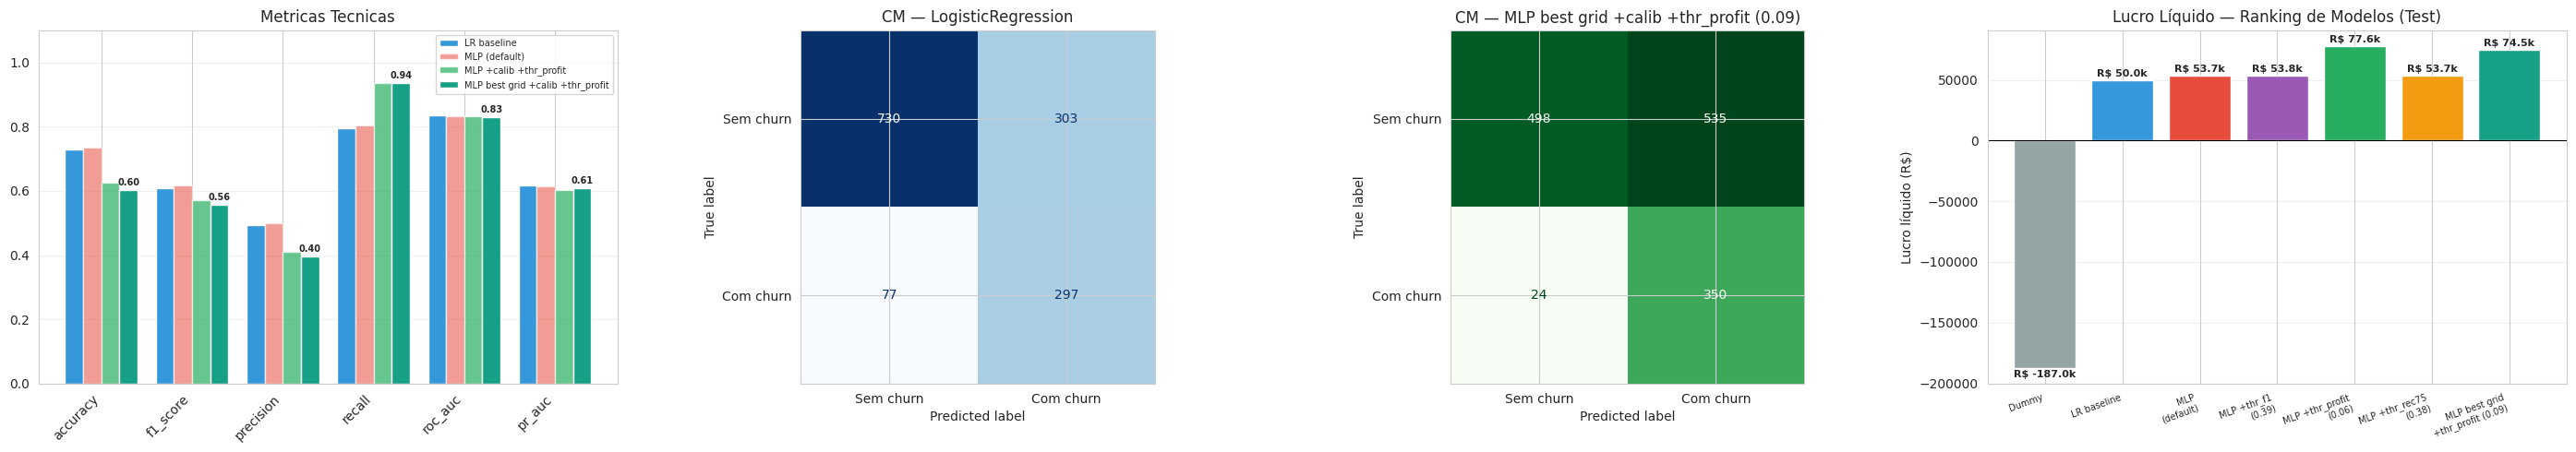

In [24]:
# Visualização final — todas as variantes do MLP vs baselines
fig, axes = plt.subplots(1, 4, figsize=(28, 5))

metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
lr_vals = [lr_metrics[m] for m in metric_names]
mlp_vals = [mlp_metrics[m] for m in metric_names]
mlp_profit_vals = [mlp_profit_metrics[m] for m in metric_names]
mlp_final_vals = [mlp_final_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.2
axes[0].bar(x - 1.5*width, lr_vals, width, label="LR baseline", color="#3498db")
axes[0].bar(x - 0.5*width, mlp_vals, width, label="MLP (default)", color="#e74c3c", alpha=0.55)
axes[0].bar(x + 0.5*width, mlp_profit_vals, width, label="MLP +calib +thr_profit", color="#27ae60", alpha=0.7)
bars_final = axes[0].bar(x + 1.5*width, mlp_final_vals, width, label="MLP best grid +calib +thr_profit", color="#16a085")
for bar in bars_final:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7, fontweight="bold",
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Metricas Tecnicas")
axes[0].legend(fontsize=7)
axes[0].grid(axis="y", alpha=0.3)

ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("CM — LogisticRegression")

ConfusionMatrixDisplay(mlp_final_cm, display_labels=["Sem churn", "Com churn"]).plot(ax=axes[2], cmap="Greens", colorbar=False)
axes[2].set_title(f"CM — MLP best grid +calib +thr_profit ({thr_final:.2f})")

# --- 4. Lucro líquido — ranking de todos os modelos ---
labels_lucro = [
    "Dummy", "LR baseline",
    "MLP\n(default)",
    f"MLP +thr_f1\n({thr_f1:.2f})",
    f"MLP +thr_profit\n({thr_profit:.2f})",
    f"MLP +thr_rec75\n({thr_rec75:.2f})",
    f"MLP best grid\n+thr_profit ({thr_final:.2f})",
]
lucros = [
    dummy_metrics["lucro_liquido_BRL"],
    lr_metrics["lucro_liquido_BRL"],
    mlp_metrics["lucro_liquido_BRL"],
    mlp_f1_metrics["lucro_liquido_BRL"],
    mlp_profit_metrics["lucro_liquido_BRL"],
    mlp_rec75_metrics["lucro_liquido_BRL"],
    mlp_final_metrics["lucro_liquido_BRL"],
]
colors = ["#95a5a6", "#3498db", "#e74c3c", "#9b59b6", "#27ae60", "#f39c12", "#16a085"]
bars = axes[3].bar(labels_lucro, lucros, color=colors)
for bar, val in zip(bars, lucros):
    axes[3].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (3000 if val >= 0 else -8000),
        f"R$ {val/1000:.1f}k", ha="center", fontsize=8, fontweight="bold",
    )
axes[3].set_ylabel("Lucro líquido (R$)")
axes[3].set_title("Lucro Líquido — Ranking de Modelos (Test)")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].grid(axis="y", alpha=0.3)
plt.setp(axes[3].xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=7)

plt.tight_layout()
plt.show()